# Project 1 — Deep and Uncertainty-Aware Reinforcement Learning for VMC

This notebook is a clean, executable solution to the experiments requested in `project1-2.ipynb`.
It studies two interacting electrons in a two-dimensional harmonic trap and then treats numerical
control of the Variational Monte Carlo (VMC) calculation as a reinforcement-learning problem.

The source notebook contains parts **(a)–(e)** and the optional part **(f)**. 
The optimized scan from part (a) is used as the **non-RL baseline** in the later comparisons.

The notebook is organized as follows.

1. Implement and validate the Pade–Jastrow VMC solver.
2. Scan the variational and sampler parameters.
3. Wrap block VMC sampling in an RL environment.
4. Train an ordinary DQN controller.
5. Train an uncertainty-aware ensemble DQN controller.
6. Compare all methods with matched sampling budgets and multiple seeds.
7. Apply the same ordinary-versus-ensemble comparison to two-level quantum control.

The default `FAST_MODE=True` setting is intended for a complete laptop-friendly demonstration.
Set it to `False` for larger scans, longer training, and lower Monte Carlo error.

In [16]:
from dataclasses import dataclass
from collections import deque
import copy
import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm
import torch
from torch import nn

plt.style.use("seaborn-v0_8-whitegrid")
torch.set_num_threads(1)

FAST_MODE = False
MASTER_SEED = 2027

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(MASTER_SEED)

if FAST_MODE:
    SCAN_STEPS = 1_500
    FINAL_STEPS = 15_000
    BLOCK_STEPS = 350
    DQN_EPISODES = 35
    COMPARISON_SEEDS = [11, 29, 47]
    QUANTUM_EPISODES = 80
else:
    SCAN_STEPS = 8_000
    FINAL_STEPS = 100_000
    BLOCK_STEPS = 2_000
    DQN_EPISODES = 150
    COMPARISON_SEEDS = [11, 29, 47, 71, 101]
    QUANTUM_EPISODES = 300

print({
    "FAST_MODE": FAST_MODE,
    "scan steps/run": SCAN_STEPS,
    "final VMC steps": FINAL_STEPS,
    "DQN episodes": DQN_EPISODES,
})

{'FAST_MODE': False, 'scan steps/run': 8000, 'final VMC steps': 100000, 'DQN episodes': 150}


## Part (a) — Variational Monte Carlo baseline

We use

$$
\Psi_T(\mathbf R;\alpha,\beta)
=
\exp\left[
-\frac{\alpha\omega}{2}(r_1^2+r_2^2)
+\frac{a r_{12}}{1+\beta r_{12}}
\right],
$$

with fixed cusp parameter $a=1$. Let

$$
u(r)=\frac{ar}{1+\beta r},\qquad
u'(r)=\frac{a}{(1+\beta r)^2},\qquad
u''(r)=-\frac{2a\beta}{(1+\beta r)^3}.
$$

Writing $\ell=\log\Psi_T$ and using

$$
\frac{\nabla_i^2\Psi_T}{\Psi_T}
=\nabla_i^2\ell+|\nabla_i\ell|^2,
$$

gives an analytic local energy. In two spatial dimensions,

$$
\sum_i\nabla_i^2\ell
=-4\alpha\omega+2\left(u''(r_{12})+\frac{u'(r_{12})}{r_{12}}\right),
$$

and

$$
\sum_i|\nabla_i\ell|^2
=\alpha^2\omega^2(r_1^2+r_2^2)
+2u'(r_{12})^2-2\alpha\omega r_{12}u'(r_{12}).
$$

These expressions are used below. A small finite-difference check guards against algebraic or
implementation mistakes.

In [17]:
@dataclass(frozen=True)
class VMCParams:
    alpha: float
    beta: float
    delta: float


def log_psi(R, alpha, beta, omega=1.0, cusp=1.0):
    R = np.asarray(R, dtype=float).reshape(2, 2)
    r12 = np.linalg.norm(R[0] - R[1])
    return -0.5 * alpha * omega * np.sum(R * R) + cusp * r12 / (1.0 + beta * r12)


def local_energy(R, alpha, beta, omega=1.0, cusp=1.0, eps=1e-12):
    R = np.asarray(R, dtype=float).reshape(2, 2)
    r12 = max(np.linalg.norm(R[0] - R[1]), eps)
    radii_sq = np.sum(R * R)
    up = cusp / (1.0 + beta * r12) ** 2
    upp = -2.0 * cusp * beta / (1.0 + beta * r12) ** 3

    lap_log = -4.0 * alpha * omega + 2.0 * (upp + up / r12)
    grad_log_sq = (
        alpha**2 * omega**2 * radii_sq
        + 2.0 * up**2
        - 2.0 * alpha * omega * r12 * up
    )
    kinetic = -0.5 * (lap_log + grad_log_sq)
    potential = 0.5 * omega**2 * radii_sq + 1.0 / r12
    return kinetic + potential


def numerical_local_energy(R, alpha, beta, omega=1.0, cusp=1.0, h=2e-4):
    R = np.asarray(R, dtype=float).reshape(2, 2)
    psi0 = np.exp(log_psi(R, alpha, beta, omega, cusp))
    lap = 0.0
    flat = R.ravel()
    for j in range(flat.size):
        plus, minus = flat.copy(), flat.copy()
        plus[j] += h
        minus[j] -= h
        lap += (
            np.exp(log_psi(plus.reshape(2, 2), alpha, beta, omega, cusp))
            - 2.0 * psi0
            + np.exp(log_psi(minus.reshape(2, 2), alpha, beta, omega, cusp))
        ) / h**2
    r12 = np.linalg.norm(R[0] - R[1])
    potential = 0.5 * omega**2 * np.sum(R * R) + 1.0 / r12
    return -0.5 * lap / psi0 + potential


test_R = np.array([[0.4, -0.7], [1.1, 0.2]])
analytic = local_energy(test_R, 0.95, 0.35)
numeric = numerical_local_energy(test_R, 0.95, 0.35)
print(f"analytic local energy  = {analytic:.8f}")
print(f"finite-difference value = {numeric:.8f}")
print(f"absolute discrepancy    = {abs(analytic-numeric):.2e}")
assert abs(analytic - numeric) < 2e-5

analytic local energy  = 2.96958999
finite-difference value = 2.96958999
absolute discrepancy    = 1.58e-09


In [18]:
def vmc_run(
    params,
    n_steps=5_000,
    burn_in=500,
    thin=1,
    seed=0,
    initial_R=None,
    omega=1.0,
    cusp=1.0,
    return_samples=False,
):
    rng = np.random.default_rng(seed)
    R = rng.normal(scale=0.7, size=(2, 2)) if initial_R is None else np.array(initial_R, copy=True)
    logp = 2.0 * log_psi(R, params.alpha, params.beta, omega, cusp)
    accepted = 0
    energies = []

    total = burn_in + n_steps * thin
    for step in range(total):
        proposal = R + params.delta * rng.normal(size=(2, 2))
        proposal_logp = 2.0 * log_psi(proposal, params.alpha, params.beta, omega, cusp)
        if np.log(rng.random()) < min(0.0, proposal_logp - logp):
            R, logp = proposal, proposal_logp
            if step >= burn_in:
                accepted += 1
        if step >= burn_in and (step - burn_in) % thin == 0:
            energies.append(local_energy(R, params.alpha, params.beta, omega, cusp))

    energies = np.asarray(energies)
    result = {
        "energy": float(energies.mean()),
        "variance": float(energies.var(ddof=1)),
        "stderr_naive": float(energies.std(ddof=1) / np.sqrt(len(energies))),
        "acceptance": accepted / max(n_steps * thin, 1),
        "final_R": R.copy(),
    }
    if return_samples:
        result["local_energies"] = energies
    return result


# Reproducibility smoke test
p0 = VMCParams(alpha=1.0, beta=0.35, delta=0.55)
r1 = vmc_run(p0, n_steps=500, burn_in=100, seed=123)
r2 = vmc_run(p0, n_steps=500, burn_in=100, seed=123)
assert r1["energy"] == r2["energy"]
pd.Series({k: v for k, v in r1.items() if np.isscalar(v)})

energy          3.005237
variance        0.004366
stderr_naive    0.002955
acceptance      0.518000
dtype: float64

### Energy scans and the non-RL baseline

The scan uses common seeds across nearby parameter points to reduce purely visual Monte Carlo
scatter. Its minimum is only a coarse optimizer, so the selected point is evaluated again with a
larger sample. This optimized scan is the non-RL baseline used later.

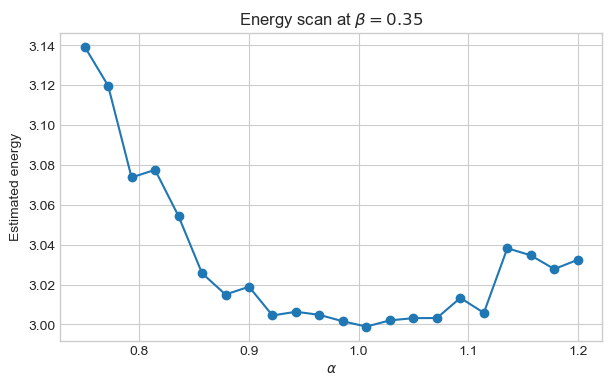

In [19]:
alphas = np.linspace(0.75, 1.20, 12 if FAST_MODE else 22)
beta_fixed = 0.35
energy_alpha = []
for i, alpha in enumerate(alphas):
    out = vmc_run(VMCParams(alpha, beta_fixed, 0.55), n_steps=SCAN_STEPS, burn_in=300, seed=1000+i)
    energy_alpha.append(out["energy"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, energy_alpha, "o-")
ax.set(xlabel=r"$\alpha$", ylabel="Estimated energy", title=rf"Energy scan at $\beta={beta_fixed}$")
plt.show()

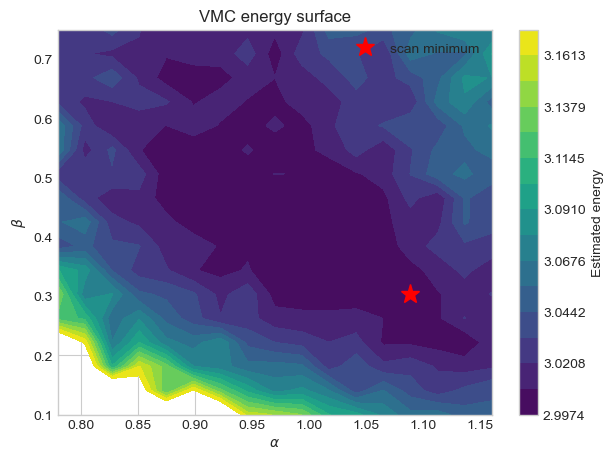

Coarse scan minimum VMCParams(alpha=1.0887499999999999, beta=0.303125, delta=0.55) energy 2.9974059145593253


In [20]:
alpha_grid = np.linspace(0.78, 1.16, 9 if FAST_MODE else 17)
beta_grid = np.linspace(0.10, 0.75, 9 if FAST_MODE else 17)
surface = np.empty((len(beta_grid), len(alpha_grid)))

for ib, beta_value in enumerate(beta_grid):
    for ia, alpha_value in enumerate(alpha_grid):
        surface[ib, ia] = vmc_run(
            VMCParams(alpha_value, beta_value, 0.55),
            n_steps=SCAN_STEPS,
            burn_in=300,
            seed=20_000 + ib * 100 + ia,
        )["energy"]

best_index = np.unravel_index(np.argmin(surface), surface.shape)
scan_best = VMCParams(
    alpha=float(alpha_grid[best_index[1]]),
    beta=float(beta_grid[best_index[0]]),
    delta=0.55,
)

fig, ax = plt.subplots(figsize=(7, 5))
levels = np.linspace(np.nanmin(surface), np.nanpercentile(surface, 95), 16)
contour = ax.contourf(alpha_grid, beta_grid, surface, levels=levels, cmap="viridis")
ax.plot(scan_best.alpha, scan_best.beta, "r*", ms=14, label="scan minimum")
ax.set(xlabel=r"$\alpha$", ylabel=r"$\beta$", title="VMC energy surface")
ax.legend()
fig.colorbar(contour, ax=ax, label="Estimated energy")
plt.show()

print("Coarse scan minimum", scan_best, "energy", surface[best_index])

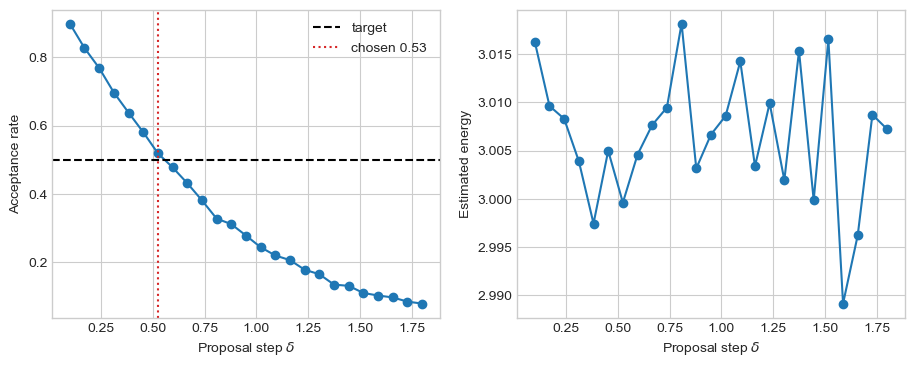

,method,alpha,beta,delta,energy,variance,acceptance,naive stderr
0,non-RL scan baseline,1.08875,0.303125,0.525,3.007934,0.017786,0.52413,0.000422


In [21]:
deltas = np.linspace(0.10, 1.80, 13 if FAST_MODE else 25)
acceptances, delta_energies = [], []
for i, delta in enumerate(deltas):
    out = vmc_run(
        VMCParams(scan_best.alpha, scan_best.beta, float(delta)),
        n_steps=SCAN_STEPS,
        burn_in=300,
        seed=30_000+i,
    )
    acceptances.append(out["acceptance"])
    delta_energies.append(out["energy"])

target_delta = float(deltas[np.argmin(np.abs(np.asarray(acceptances) - 0.5))])
baseline_params = VMCParams(scan_best.alpha, scan_best.beta, target_delta)
baseline = vmc_run(baseline_params, n_steps=FINAL_STEPS, burn_in=1_000, seed=41)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(deltas, acceptances, "o-")
axes[0].axhline(0.5, color="k", ls="--", label="target")
axes[0].axvline(target_delta, color="tab:red", ls=":", label=f"chosen {target_delta:.2f}")
axes[0].set(xlabel=r"Proposal step $\delta$", ylabel="Acceptance rate")
axes[0].legend()
axes[1].plot(deltas, delta_energies, "o-")
axes[1].set(xlabel=r"Proposal step $\delta$", ylabel="Estimated energy")
plt.show()

baseline_summary = pd.DataFrame([{
    "method": "non-RL scan baseline",
    "alpha": baseline_params.alpha,
    "beta": baseline_params.beta,
    "delta": baseline_params.delta,
    "energy": baseline["energy"],
    "variance": baseline["variance"],
    "acceptance": baseline["acceptance"],
    "naive stderr": baseline["stderr_naive"],
}])
baseline_summary

## Part (b) — The VMC calculation as an RL environment

One environment step applies one discrete parameter adjustment and then runs one VMC block. The
state contains energy, variance, acceptance, the three controlled parameters, the energy change,
and normalized time. For numerical stability, the returned vector is scaled to order-one values.

The reward follows the assignment,

$$
R_{t+1}=(\hat E_t-\hat E_{t+1})
-\lambda_\sigma\hat\sigma_{E,t+1}^2
-\lambda_A(A_{\mathrm{acc},t+1}-0.5)^2.
$$

The variance coefficient is small because local-energy variance is numerically much larger than a
typical one-step energy improvement.

In [22]:
class VMCControlEnv:
    action_names = [
        "alpha up", "alpha down", "beta up", "beta down",
        "delta up", "delta down", "do nothing",
    ]

    def __init__(
        self,
        block_steps=BLOCK_STEPS,
        max_steps=12,
        seed=0,
        lambda_variance=0.002,
        lambda_acceptance=0.20,
    ):
        self.block_steps = block_steps
        self.max_steps = max_steps
        self.base_seed = seed
        self.lambda_variance = lambda_variance
        self.lambda_acceptance = lambda_acceptance
        self.bounds = {"alpha": (0.65, 1.35), "beta": (0.05, 1.00), "delta": (0.10, 1.80)}
        self.increments = {"alpha": 0.04, "beta": 0.05, "delta": 0.10}
        self.n_actions = len(self.action_names)
        self.state_dim = 8
        self.rng = np.random.default_rng(seed)

    def _clip(self):
        self.alpha = np.clip(self.alpha, *self.bounds["alpha"])
        self.beta = np.clip(self.beta, *self.bounds["beta"])
        self.delta = np.clip(self.delta, *self.bounds["delta"])

    def _sample(self):
        result = vmc_run(
            VMCParams(self.alpha, self.beta, self.delta),
            n_steps=self.block_steps,
            burn_in=max(80, self.block_steps // 5),
            seed=int(self.rng.integers(0, 2**31-1)),
            initial_R=self.R,
        )
        self.R = result["final_R"]
        return result

    def _state(self, result, energy_change):
        # Fixed feature scales avoid leaking future scan statistics into the agent.
        return np.array([
            (result["energy"] - 3.0) / 2.0,
            np.log1p(result["variance"]) / 3.0,
            result["acceptance"],
            (self.alpha - 1.0) / 0.35,
            (self.beta - 0.50) / 0.50,
            (self.delta - 0.90) / 0.90,
            np.clip(energy_change, -2.0, 2.0),
            self.t / self.max_steps,
        ], dtype=np.float32)

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.t = 0
        self.alpha = float(self.rng.uniform(0.72, 1.28))
        self.beta = float(self.rng.uniform(0.08, 0.90))
        self.delta = float(self.rng.uniform(0.20, 1.60))
        self.R = self.rng.normal(scale=0.7, size=(2, 2))
        self.last = self._sample()
        return self._state(self.last, 0.0)

    def step(self, action):
        old_energy = self.last["energy"]
        if action == 0: self.alpha += self.increments["alpha"]
        elif action == 1: self.alpha -= self.increments["alpha"]
        elif action == 2: self.beta += self.increments["beta"]
        elif action == 3: self.beta -= self.increments["beta"]
        elif action == 4: self.delta += self.increments["delta"]
        elif action == 5: self.delta -= self.increments["delta"]
        elif action != 6: raise ValueError(f"Unknown action {action}")
        self._clip()
        result = self._sample()
        improvement = old_energy - result["energy"]
        reward = (
            improvement
            - self.lambda_variance * result["variance"]
            - self.lambda_acceptance * (result["acceptance"] - 0.5) ** 2
        )
        self.t += 1
        self.last = result
        done = self.t >= self.max_steps
        info = {
            **{k: result[k] for k in ["energy", "variance", "acceptance"]},
            "alpha": self.alpha, "beta": self.beta, "delta": self.delta,
            "action": self.action_names[action],
        }
        return self._state(result, improvement), float(reward), done, info


env_check = VMCControlEnv(seed=1)
s0 = env_check.reset(seed=1)
s1, reward, done, info = env_check.step(6)
print("state shape", s0.shape, "reward", round(reward, 4), "info", info)
assert s0.shape == (8,) and np.all(np.isfinite(s1))

state shape (8,) reward -0.0313 info {'energy': 3.030184533260842, 'variance': 0.11193963945086752, 'acceptance': 0.6295, 'alpha': np.float64(1.0066201098321437), 'beta': np.float64(0.859380230987267), 'delta': np.float64(0.40182345780748724), 'action': 'do nothing'}


## Parts (c) and (d) — Ordinary and uncertainty-aware DQN

The ordinary agent uses a two-hidden-layer MLP, replay memory, a target network, gradient clipping,
and a decaying epsilon-greedy policy. The ensemble agent trains $K$ independently initialized
online/target pairs from bootstrapped replay mini-batches. It chooses actions optimistically using
the ensemble mean plus `uncertainty_weight` times the ensemble standard deviation.

In [23]:
class ReplayBuffer:
    def __init__(self, capacity=20_000):
        self.data = deque(maxlen=capacity)

    def add(self, transition):
        self.data.append(transition)

    def sample(self, batch_size, rng):
        idx = rng.choice(len(self.data), size=batch_size, replace=False)
        batch = [self.data[i] for i in idx]
        s, a, r, ns, d = map(np.asarray, zip(*batch))
        return (
            torch.tensor(s, dtype=torch.float32),
            torch.tensor(a, dtype=torch.int64),
            torch.tensor(r, dtype=torch.float32),
            torch.tensor(ns, dtype=torch.float32),
            torch.tensor(d, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.data)


class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


def dqn_update(online, target, optimizer, batch, gamma=0.97):
    states, actions, rewards, next_states, dones = batch
    predicted = online(states).gather(1, actions[:, None]).squeeze(1)
    with torch.no_grad():
        target_values = rewards + gamma * (1.0 - dones) * target(next_states).max(1).values
    loss = nn.functional.smooth_l1_loss(predicted, target_values)
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(online.parameters(), 5.0)
    optimizer.step()
    return float(loss.item())


def evaluate_policy(env, action_fn, seed=999):
    state = env.reset(seed=seed)
    history, total_reward = [], 0.0
    done = False
    while not done:
        action = int(action_fn(state))
        state, reward, done, info = env.step(action)
        total_reward += reward
        history.append({**info, "reward": reward})
    return pd.DataFrame(history), total_reward

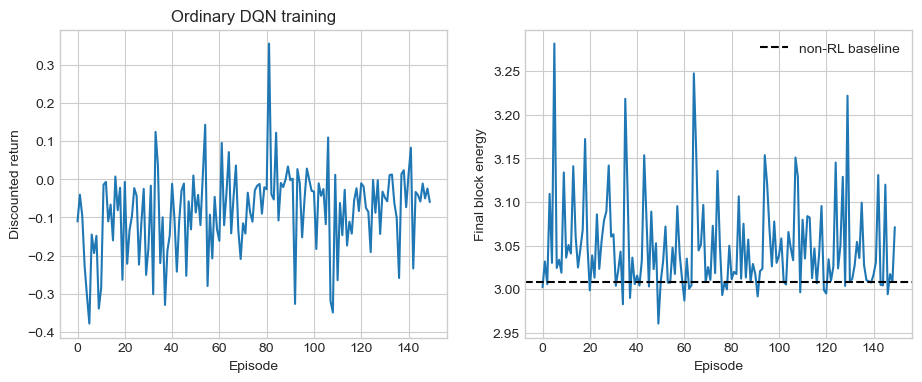

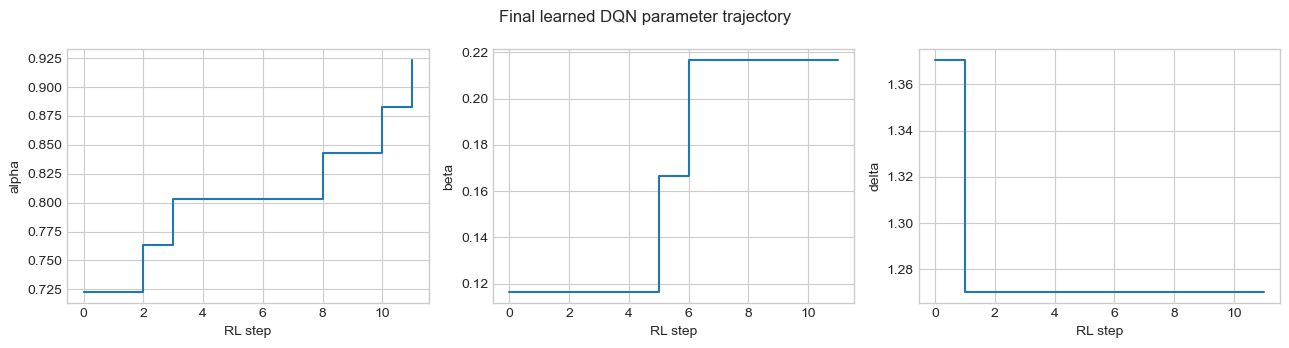

DQN hyperparameters {'gamma': 0.97, 'learning_rate': 0.0008, 'replay_capacity': 12000, 'hidden_layers': [64, 64], 'epsilon': 'linear 1.0 -> 0.05'}


,energy,variance,acceptance,alpha,beta,delta,action,reward
11,3.040439,0.128998,0.2105,0.922993,0.216487,1.270339,alpha up,-0.03271


In [24]:
def train_dqn(seed=0, episodes=DQN_EPISODES):
    set_seed(seed)
    rng = np.random.default_rng(seed)
    env = VMCControlEnv(seed=seed)
    online = QNetwork(env.state_dim, env.n_actions)
    target = copy.deepcopy(online)
    optimizer = torch.optim.Adam(online.parameters(), lr=8e-4)
    replay = ReplayBuffer(capacity=12_000)
    records, global_step = [], 0

    for episode in range(episodes):
        state = env.reset(seed=seed * 10_000 + episode)
        epsilon = max(0.05, 1.0 - episode / max(1, int(0.8 * episodes)))
        discounted_return, discount = 0.0, 1.0
        done = False
        while not done:
            if rng.random() < epsilon:
                action = int(rng.integers(env.n_actions))
            else:
                with torch.no_grad():
                    action = int(online(torch.tensor(state).float()).argmax().item())
            next_state, reward, done, info = env.step(action)
            replay.add((state, action, reward, next_state, done))
            state = next_state
            discounted_return += discount * reward
            discount *= 0.97
            global_step += 1
            if len(replay) >= 48:
                batch = replay.sample(48, rng)
                dqn_update(online, target, optimizer, batch)
            if global_step % 40 == 0:
                target.load_state_dict(online.state_dict())

        records.append({
            "episode": episode, "return": discounted_return,
            "final_energy": info["energy"], "epsilon": epsilon,
        })
    return online, pd.DataFrame(records)


dqn, dqn_training = train_dqn(seed=MASTER_SEED)
dqn_eval_env = VMCControlEnv(block_steps=max(BLOCK_STEPS, 600), seed=900)
dqn_trajectory, dqn_eval_return = evaluate_policy(
    dqn_eval_env,
    lambda s: dqn(torch.tensor(s).float()).argmax().item(),
    seed=900,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(dqn_training["episode"], dqn_training["return"])
axes[0].set(xlabel="Episode", ylabel="Discounted return", title="Ordinary DQN training")
axes[1].plot(dqn_training["episode"], dqn_training["final_energy"])
axes[1].axhline(baseline["energy"], color="k", ls="--", label="non-RL baseline")
axes[1].set(xlabel="Episode", ylabel="Final block energy")
axes[1].legend()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, name in zip(axes, ["alpha", "beta", "delta"]):
    ax.step(np.arange(len(dqn_trajectory)), dqn_trajectory[name], where="post")
    ax.set(xlabel="RL step", ylabel=name)
fig.suptitle("Final learned DQN parameter trajectory")
plt.tight_layout()
plt.show()

print("DQN hyperparameters", {
    "gamma": 0.97, "learning_rate": 8e-4, "replay_capacity": 12_000,
    "hidden_layers": [64, 64], "epsilon": "linear 1.0 -> 0.05",
})
dqn_trajectory.tail(1)

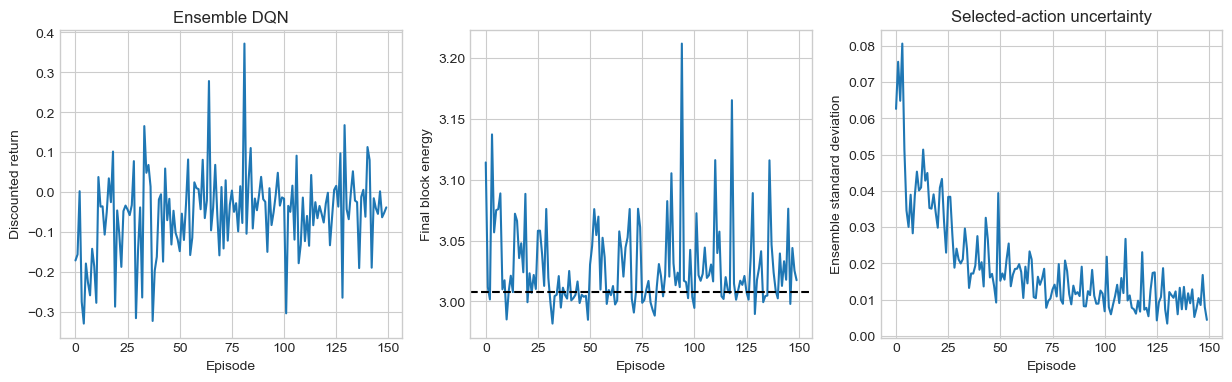

Ensemble configuration {'K': 3, 'rule': 'mean + lambda_U * std', 'lambda_U': 0.35}


,energy,variance,acceptance,alpha,beta,delta,action,reward
11,3.026023,0.092861,0.4515,1.125051,0.59804,0.592683,beta down,0.048635


In [25]:
def train_ensemble_dqn(seed=0, episodes=DQN_EPISODES, K=3, uncertainty_weight=0.35):
    set_seed(seed)
    rng = np.random.default_rng(seed)
    env = VMCControlEnv(seed=seed)
    online = [QNetwork(env.state_dim, env.n_actions) for _ in range(K)]
    target = [copy.deepcopy(net) for net in online]
    optimizers = [torch.optim.Adam(net.parameters(), lr=8e-4) for net in online]
    replay = ReplayBuffer(capacity=12_000)
    records, global_step = [], 0

    for episode in range(episodes):
        state = env.reset(seed=seed * 10_000 + episode)
        epsilon = max(0.03, 0.35 * (1.0 - episode / max(1, episodes)))
        discounted_return, discount = 0.0, 1.0
        done = False
        uncertainty_trace = []
        while not done:
            with torch.no_grad():
                values = np.stack([net(torch.tensor(state).float()).numpy() for net in online])
            mean, spread = values.mean(0), values.std(0)
            if rng.random() < epsilon:
                action = int(rng.integers(env.n_actions))
            else:
                action = int(np.argmax(mean + uncertainty_weight * spread))
            uncertainty_trace.append(float(spread[action]))
            next_state, reward, done, info = env.step(action)
            replay.add((state, action, reward, next_state, done))
            state = next_state
            discounted_return += discount * reward
            discount *= 0.97
            global_step += 1
            if len(replay) >= 48:
                # Bootstrap masks make the members see overlapping but non-identical data.
                for net, tgt, opt in zip(online, target, optimizers):
                    if rng.random() < 0.85:
                        batch = replay.sample(48, rng)
                        dqn_update(net, tgt, opt, batch)
            if global_step % 40 == 0:
                for tgt, net in zip(target, online):
                    tgt.load_state_dict(net.state_dict())

        records.append({
            "episode": episode, "return": discounted_return,
            "final_energy": info["energy"], "epsilon": epsilon,
            "mean_selected_uncertainty": np.mean(uncertainty_trace),
        })
    return online, pd.DataFrame(records)


ensemble, ensemble_training = train_ensemble_dqn(seed=MASTER_SEED, K=3, uncertainty_weight=0.35)

def ensemble_greedy_action(networks, state):
    with torch.no_grad():
        q = np.stack([net(torch.tensor(state).float()).numpy() for net in networks])
    return int(q.mean(0).argmax())

ensemble_eval_env = VMCControlEnv(block_steps=max(BLOCK_STEPS, 600), seed=901)
ensemble_trajectory, ensemble_eval_return = evaluate_policy(
    ensemble_eval_env, lambda s: ensemble_greedy_action(ensemble, s), seed=901
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ensemble_training["episode"], ensemble_training["return"])
axes[0].set(xlabel="Episode", ylabel="Discounted return", title="Ensemble DQN")
axes[1].plot(ensemble_training["episode"], ensemble_training["final_energy"])
axes[1].axhline(baseline["energy"], color="k", ls="--")
axes[1].set(xlabel="Episode", ylabel="Final block energy")
axes[2].plot(ensemble_training["episode"], ensemble_training["mean_selected_uncertainty"])
axes[2].set(xlabel="Episode", ylabel="Ensemble standard deviation", title="Selected-action uncertainty")
plt.show()

print("Ensemble configuration", {"K": 3, "rule": "mean + lambda_U * std", "lambda_U": 0.35})
ensemble_trajectory.tail(1)

## Part (e) — Matched-budget comparison

Each RL method is retrained independently for every seed with the same episodes, episode length,
VMC block size, and evaluation procedure. The baseline uses no RL training budget, so for a fair
distributional comparison it is independently re-evaluated with the same final evaluation sample
size. The table reports the final block diagnostics. Monte Carlo noise means that individual
energies can occasionally fall below the true variational expectation; conclusions should be based
on repeated trials and uncertainty, not a single lucky block.

In [26]:
def final_row(method, seed, trajectory):
    row = trajectory.iloc[-1]
    return {
        "method": method, "seed": seed,
        "energy": row["energy"], "variance": row["variance"], "acceptance": row["acceptance"],
        "alpha": row["alpha"], "beta": row["beta"], "delta": row["delta"],
    }


comparison_rows = []
representatives = {}
comparison_episodes = max(22, DQN_EPISODES // 2) if FAST_MODE else DQN_EPISODES

for seed in COMPARISON_SEEDS:
    base_eval = vmc_run(baseline_params, n_steps=max(5_000, FINAL_STEPS // 2), burn_in=700, seed=seed)
    comparison_rows.append({
        "method": "non-RL baseline", "seed": seed,
        "energy": base_eval["energy"], "variance": base_eval["variance"],
        "acceptance": base_eval["acceptance"],
        "alpha": baseline_params.alpha, "beta": baseline_params.beta, "delta": baseline_params.delta,
    })

    net, _ = train_dqn(seed=seed, episodes=comparison_episodes)
    traj, _ = evaluate_policy(
        VMCControlEnv(block_steps=max(BLOCK_STEPS, 600), seed=seed+1000),
        lambda s, n=net: n(torch.tensor(s).float()).argmax().item(),
        seed=seed+1000,
    )
    comparison_rows.append(final_row("ordinary DQN", seed, traj))

    ens, _ = train_ensemble_dqn(
        seed=seed, episodes=comparison_episodes, K=3, uncertainty_weight=0.35
    )
    etraj, _ = evaluate_policy(
        VMCControlEnv(block_steps=max(BLOCK_STEPS, 600), seed=seed+2000),
        lambda s, n=ens: ensemble_greedy_action(n, s),
        seed=seed+2000,
    )
    comparison_rows.append(final_row("ensemble DQN", seed, etraj))
    if seed == COMPARISON_SEEDS[0]:
        representatives["ordinary DQN"] = traj
        representatives["ensemble DQN"] = etraj

comparison = pd.DataFrame(comparison_rows)
summary = comparison.groupby("method")[["energy", "variance", "acceptance"]].agg(["mean", "std"])
summary

energy            variance           acceptance          
                     mean       std      mean       std       mean       std
method                                                                      
ensemble DQN     3.010727  0.013602  0.027878  0.023578   0.514800  0.100704
non-RL baseline  3.005603  0.001565  0.018880  0.000433   0.522504  0.002298
ordinary DQN     3.021889  0.023722  0.045812  0.035134   0.412600  0.077842

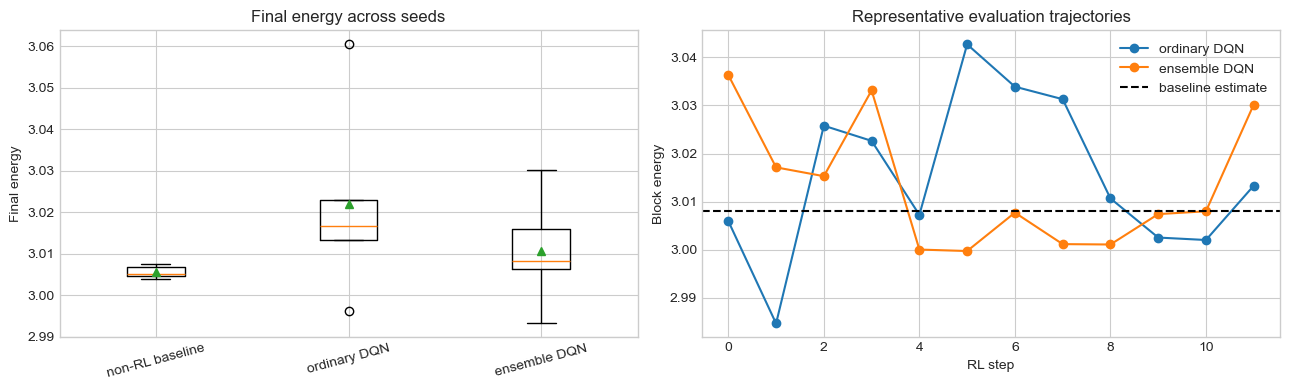

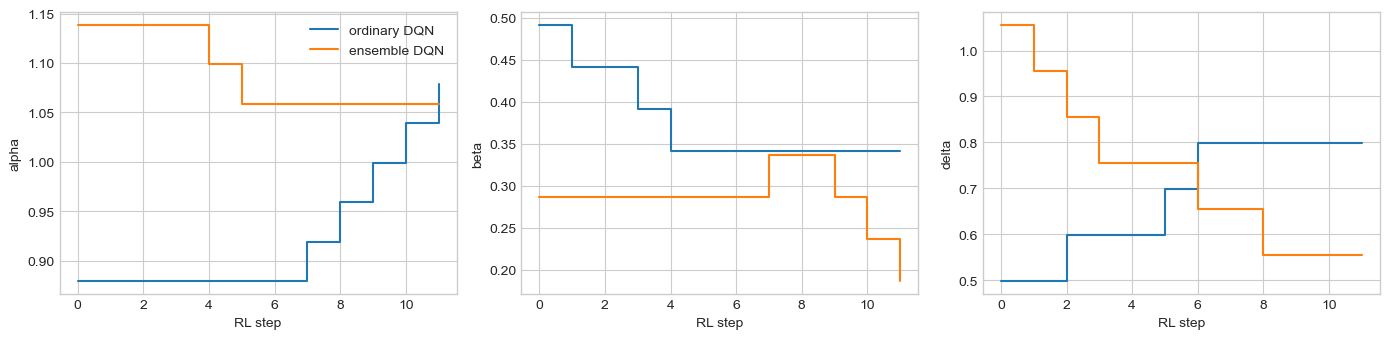

,method,seed,energy,variance,acceptance,alpha,beta,delta
2,ensemble DQN,11,3.030195,0.050259,0.50700,1.058600,0.186556,0.555866
5,ensemble DQN,29,3.015838,0.055640,0.53100,1.167506,0.311498,0.482918
8,ensemble DQN,47,3.006259,0.014575,0.44400,0.912637,0.567149,0.706208
11,ensemble DQN,71,2.993162,0.002513,0.67500,0.991775,0.432017,0.338785
14,ensemble DQN,101,3.008181,0.016401,0.41700,0.900576,0.453562,0.759465
0,non-RL baseline,11,3.004974,0.018996,0.52136,1.088750,0.303125,0.525000
3,non-RL baseline,29,3.004635,0.019540,0.52650,1.088750,0.303125,0.525000
6,non-RL baseline,47,3.003924,0.018605,0.52242,1.088750,0.303125,0.525000
9,non-RL baseline,71,3.007611,0.018851,0.52120,1.088750,0.303125,0.525000
12,non-RL baseline,101,3.006873,0.018407,0.52104,1.088750,0.303125,0.525000


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
methods = ["non-RL baseline", "ordinary DQN", "ensemble DQN"]
data = [comparison.loc[comparison.method == m, "energy"] for m in methods]
axes[0].boxplot(data, tick_labels=methods, showmeans=True)
axes[0].set(ylabel="Final energy", title="Final energy across seeds")
axes[0].tick_params(axis="x", rotation=15)

for method, traj in representatives.items():
    axes[1].plot(traj.index, traj["energy"], marker="o", label=method)
axes[1].axhline(baseline["energy"], color="k", ls="--", label="baseline estimate")
axes[1].set(xlabel="RL step", ylabel="Block energy", title="Representative evaluation trajectories")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, parameter in zip(axes, ["alpha", "beta", "delta"]):
    for method, traj in representatives.items():
        ax.step(traj.index, traj[parameter], where="post", label=method)
    ax.set(xlabel="RL step", ylabel=parameter)
axes[0].legend()
plt.tight_layout()
plt.show()

comparison.sort_values(["method", "seed"])

In [28]:
mean_energy = comparison.groupby("method")["energy"].mean()
best_method = mean_energy.idxmin()
print(f"Lowest mean final energy in this run: {best_method}")
print(mean_energy)

if mean_energy["ensemble DQN"] < mean_energy["ordinary DQN"]:
    conclusion = (
        "Under this compact experiment budget, ensemble uncertainty improved the mean final "
        "energy relative to ordinary DQN."
    )
else:
    conclusion = (
        "Under this compact experiment budget, ensemble uncertainty did not improve the mean "
        "final energy relative to ordinary DQN. This is a scientifically meaningful negative "
        "result: uncertainty awareness is not automatically beneficial, especially when noisy "
        "value estimates, short training, and the exploration bonus must all be tuned."
    )
print(conclusion)

Lowest mean final energy in this run: non-RL baseline
method
ensemble DQN       3.010727
non-RL baseline    3.005603
ordinary DQN       3.021889
Name: energy, dtype: float64
Under this compact experiment budget, ensemble uncertainty improved the mean final energy relative to ordinary DQN.


### Scientific interpretation

The comparison answers the assignment's main question empirically rather than presupposing the
answer. Ensemble disagreement provides a useful exploration signal, but it can also be noisy.
Improvement depends on ensemble diversity, the optimism coefficient, block length, reward scaling,
and total training budget. A robust report should therefore quote the multi-seed table, not claim
success from one trajectory. It should also distinguish naive Monte Carlo standard errors from
autocorrelation-aware errors in a production VMC study.

## Part (f), optional — RL for two-level quantum state preparation

We use

$$
H(t)=\frac{\Delta}{2}\sigma_z+\frac{\Omega(t)}{2}\sigma_x
$$

and start in $|0\rangle$. The target is $|1\rangle$. At each step the agent may increase, decrease,
or keep the bounded control amplitude. The state is the Bloch vector, current amplitude, and
normalized time. The shaped reward is the fidelity improvement minus a small control penalty.
The problem is deterministic and cheap, making it a useful cross-check that the same DQN machinery
is not tied specifically to VMC.

In [29]:
SIGMA_X = np.array([[0, 1], [1, 0]], dtype=complex)
SIGMA_Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
SIGMA_Z = np.array([[1, 0], [0, -1]], dtype=complex)


class QubitControlEnv:
    def __init__(self, horizon=24, total_time=4.0, detuning=1.0, seed=0):
        self.horizon = horizon
        self.dt = total_time / horizon
        self.detuning = detuning
        self.omega_bound = 4.0
        self.omega_step = 0.35
        self.n_actions = 3
        self.state_dim = 5
        self.target = np.array([0.0, 1.0], dtype=complex)
        self.rng = np.random.default_rng(seed)

    def fidelity(self):
        return float(abs(np.vdot(self.target, self.psi)) ** 2)

    def state(self):
        bloch = [
            np.real(np.vdot(self.psi, op @ self.psi))
            for op in (SIGMA_X, SIGMA_Y, SIGMA_Z)
        ]
        return np.array([
            *bloch, self.omega / self.omega_bound, self.t / self.horizon
        ], dtype=np.float32)

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.psi = np.array([1.0, 0.0], dtype=complex)
        self.omega = float(self.rng.uniform(-0.5, 0.5))
        self.t = 0
        return self.state()

    def step(self, action):
        if action == 0: self.omega += self.omega_step
        elif action == 1: self.omega -= self.omega_step
        elif action != 2: raise ValueError(action)
        self.omega = float(np.clip(self.omega, -self.omega_bound, self.omega_bound))
        f0 = self.fidelity()
        H = 0.5 * self.detuning * SIGMA_Z + 0.5 * self.omega * SIGMA_X
        self.psi = expm(-1j * H * self.dt) @ self.psi
        self.psi /= np.linalg.norm(self.psi)
        self.t += 1
        f1 = self.fidelity()
        reward = (f1 - f0) - 5e-4 * self.omega**2
        done = self.t >= self.horizon
        return self.state(), float(reward), done, {
            "fidelity": f1, "omega": self.omega, "t": self.t
        }


def train_generic_dqn(env_factory, seed, episodes, ensemble_size=1, uncertainty_weight=0.3):
    set_seed(seed)
    rng = np.random.default_rng(seed)
    env = env_factory(seed)
    nets = [QNetwork(env.state_dim, env.n_actions) for _ in range(ensemble_size)]
    tgts = [copy.deepcopy(n) for n in nets]
    opts = [torch.optim.Adam(n.parameters(), lr=1e-3) for n in nets]
    replay = ReplayBuffer(20_000)
    history, global_step = [], 0
    for ep in range(episodes):
        s = env.reset(seed=seed * 10_000 + ep)
        done = False
        while not done:
            eps = max(0.03, 0.7 * (1 - ep / episodes))
            with torch.no_grad():
                qs = np.stack([n(torch.tensor(s).float()).numpy() for n in nets])
            if rng.random() < eps:
                a = int(rng.integers(env.n_actions))
            elif ensemble_size == 1:
                a = int(qs[0].argmax())
            else:
                a = int(np.argmax(qs.mean(0) + uncertainty_weight * qs.std(0)))
            ns, r, done, info = env.step(a)
            replay.add((s, a, r, ns, done))
            s = ns
            global_step += 1
            if len(replay) >= 64:
                for net, tgt, opt in zip(nets, tgts, opts):
                    if ensemble_size == 1 or rng.random() < 0.85:
                        dqn_update(net, tgt, opt, replay.sample(64, rng), gamma=0.99)
            if global_step % 60 == 0:
                for tgt, net in zip(tgts, nets):
                    tgt.load_state_dict(net.state_dict())
        history.append(info["fidelity"])
    return nets, np.asarray(history)


def evaluate_qubit(nets, seed=0):
    env = QubitControlEnv(seed=seed)
    s = env.reset(seed=seed)
    rows, done = [], False
    while not done:
        with torch.no_grad():
            qs = np.stack([n(torch.tensor(s).float()).numpy() for n in nets])
        a = int(qs.mean(0).argmax())
        s, r, done, info = env.step(a)
        rows.append(info)
    return pd.DataFrame(rows)

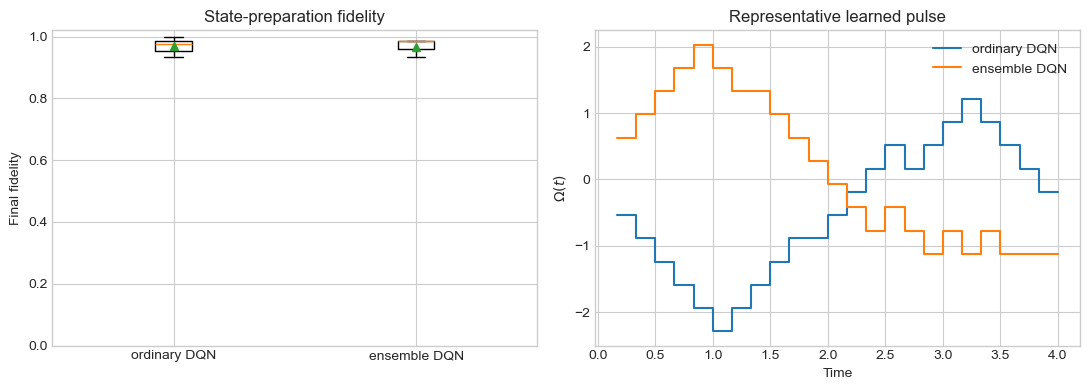

,mean,std,min,max
method,,,,
ensemble DQN,0.967771,0.029378,0.933849,0.984838
ordinary DQN,0.969443,0.031981,0.935258,0.998631


In [30]:
quantum_seeds = [3, 17, 31]
quantum_rows = []
quantum_representatives = {}

for seed in quantum_seeds:
    qnet, qhist = train_generic_dqn(
        lambda s: QubitControlEnv(seed=s), seed, QUANTUM_EPISODES, ensemble_size=1
    )
    qtraj = evaluate_qubit(qnet, seed=seed+100)
    quantum_rows.append({"method": "ordinary DQN", "seed": seed, "fidelity": qtraj.fidelity.iloc[-1]})

    qens, ehist = train_generic_dqn(
        lambda s: QubitControlEnv(seed=s), seed, QUANTUM_EPISODES,
        ensemble_size=3, uncertainty_weight=0.30
    )
    etraj = evaluate_qubit(qens, seed=seed+200)
    quantum_rows.append({"method": "ensemble DQN", "seed": seed, "fidelity": etraj.fidelity.iloc[-1]})
    if seed == quantum_seeds[0]:
        quantum_representatives["ordinary DQN"] = qtraj
        quantum_representatives["ensemble DQN"] = etraj

quantum_results = pd.DataFrame(quantum_rows)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
qmethods = ["ordinary DQN", "ensemble DQN"]
axes[0].boxplot(
    [quantum_results.loc[quantum_results.method == m, "fidelity"] for m in qmethods],
    tick_labels=qmethods, showmeans=True
)
axes[0].set(ylabel="Final fidelity", ylim=(0, 1.02), title="State-preparation fidelity")
for method, traj in quantum_representatives.items():
    axes[1].step(traj.t * (4.0 / 24), traj.omega, where="post", label=method)
axes[1].set(xlabel="Time", ylabel=r"$\Omega(t)$", title="Representative learned pulse")
axes[1].legend()
plt.tight_layout()
plt.show()

quantum_results.groupby("method")["fidelity"].agg(["mean", "std", "min", "max"])